# Understanding BERT on a Simple Medical Text Example

In this notebook, we follow one simple question:

**Can BERT recognize whether a sentence describes a medical condition?**

We will go step by step:

* First, we load a pretrained BERT model.
* We test it before training, to see that the first prediction is only a guess.
* Then we look at how text is transformed into tokens, and numerical vectors.
* We show that words are no longer handled as text, but as numerical representations.
* We compare some token vectors to see which words look similar to BERT.
* After that, we fine-tune the model on labeled medical examples.
* Finally, we test the same sentences again and look inside BERT with attention.

The goal is not only to get a prediction, but to understand what happens to a sentence inside the model.


In [107]:
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from torch.optim import AdamW
import os
import matplotlib.pyplot as plt
from torch.nn.functional import cosine_similarity

## Loading BERT

In [108]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased", num_labels=2
).to(device)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", do_lower_case=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### What does the warning tell us?

* BERT already knows many general patterns of English text.

* It can turn a sentence into a useful numerical representation.

* We add a small decision layer on top.

* This layer should decide whether the sentence describes a medical condition.

  * `0 = No Condition`
  * `1 = Medical Condition`

* At this point, this decision layer is still untrained.

* Therefore, before fine-tuning, the prediction is only a random guess.


In [109]:
test_sentence_condition = "The young female patient suffers from chronic headaches."
test_sentence_no_condition = "The hospital has a new meal plan."

In [117]:
test_sentences = [
    ("Medical", test_sentence_condition),
    ("General", test_sentence_no_condition),
]

sentence_names = [name for name, _ in test_sentences]

label_names = {0: "No Condition", 1: "Medical Condition"}

sentences = [sentence for _, sentence in test_sentences]

encoding = tokenizer(sentences, return_tensors="pt", padding=True, truncation=True)

### First prediction: before learning the task

* We first test the model before training it on our examples.
* BERT can already read the sentence and create a representation.
* However, the final decision layer has not learned our labels yet.
* Therefore, this first output is useful as a baseline, but not as a real prediction.
* After fine-tuning, we will run the same two sentences again.


In [118]:
def print_predictions(model, encoding, test_sentences, label_names, title):
    model.eval()

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

    probabilities = torch.nn.functional.softmax(logits, dim=1)
    predicted_classes = torch.argmax(probabilities, dim=1)

    print(title)
    print("=" * 70)

    for i, (sentence_type, sentence) in enumerate(test_sentences):
        predicted_class = predicted_classes[i].item()
        probs = probabilities[i].cpu().numpy()

        no_condition_prob = probs[0] * 100
        medical_condition_prob = probs[1] * 100

        print(f"{sentence_type}")
        print(f"Sentence: {sentence}")
        print()
        print("Predicted probabilities:")
        print(f"  No Condition:      {no_condition_prob:.1f}%")
        print(f"  Medical Condition: {medical_condition_prob:.1f}%")
        print()
        print(f"Final prediction: {predicted_class} ({label_names[predicted_class]})")
        print("-" * 70)


print_predictions(
    model, encoding, test_sentences, label_names, title="Prediction before fine-tuning"
)

Prediction before fine-tuning
Medical
Sentence: The young female patient suffers from chronic headaches.

Predicted probabilities:
  No Condition:      54.3%
  Medical Condition: 45.7%

Final prediction: 0 (No Condition)
----------------------------------------------------------------------
General
Sentence: The hospital has a new meal plan.

Predicted probabilities:
  No Condition:      49.9%
  Medical Condition: 50.1%

Final prediction: 1 (Medical Condition)
----------------------------------------------------------------------


## From text to BERT input

* The tokenizer prepares the sentences for BERT.
* It splits the text into smaller pieces called tokens.
* The model does not continue with the original words, but with numerical representations.


In [119]:
dfs = []

for i, name in enumerate(sentence_names):
    input_ids = encoding["input_ids"][i].tolist()
    attention_mask = encoding["attention_mask"][i].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    df_i = pd.DataFrame(
        {
            f"{name} token": tokens,
            f"{name} attention_mask": attention_mask,
        }
    )

    dfs.append(df_i)

comparison_df = pd.concat(dfs, axis=1)

comparison_df

,Medical token,Medical attention_mask,General token,General attention_mask
0,[CLS],1,[CLS],1
1,the,1,the,1
2,young,1,hospital,1
3,female,1,has,1
4,patient,1,a,1
5,suffers,1,new,1
6,from,1,meal,1
7,chronic,1,plan,1
8,headache,1,.,1
9,##s,1,[SEP],1


### Why do we see `[PAD]` tokens?

* The two sentences have different lengths.
* To process them together, BERT needs them to have the same length.
* The shorter sentence is filled up with `[PAD]` tokens.
* `[PAD]` tokens are only technical placeholders.
* Their `attention_mask` is `0`, so BERT ignores them.
* Real tokens have `attention_mask = 1`, so BERT uses them.


### How are the words represented?

* An embedding is a numerical profile of a token.
* In this BERT model, each token becomes a vector with 768 numbers.
* The heatmap shows a small visible part of these vectors.
* Each row is one token.
* Each column is one embedding dimension.
* Similar-looking patterns suggest that tokens have somewhat similar numerical representations.


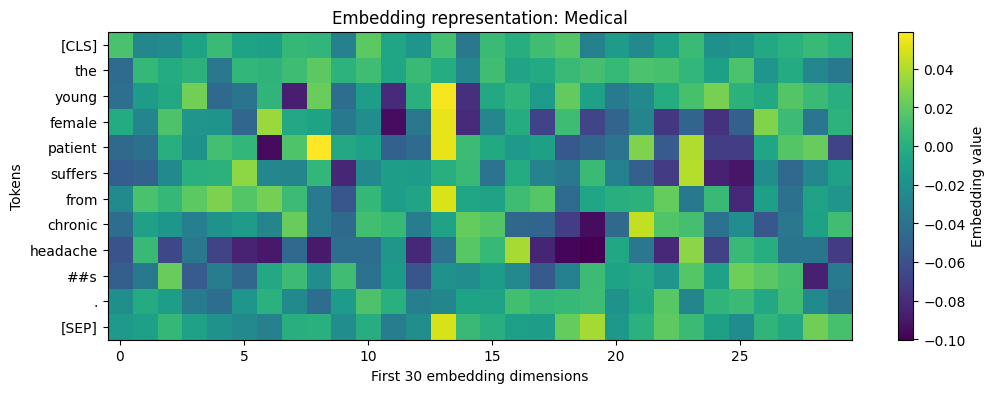

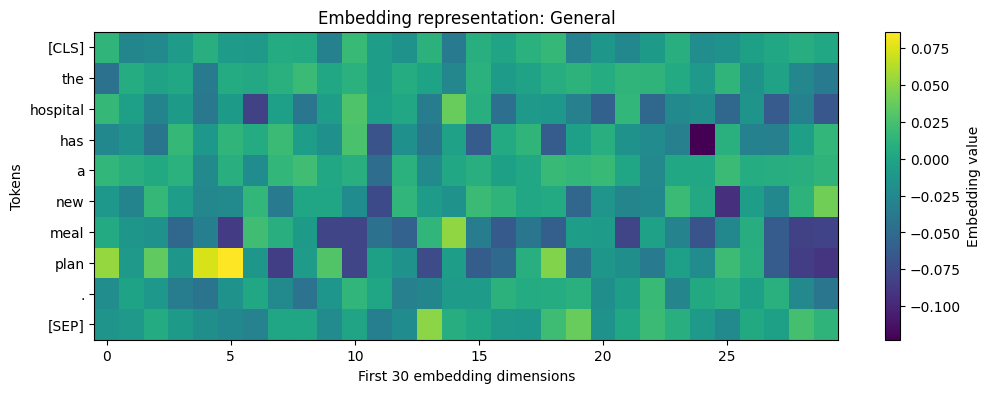

In [120]:
input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)

model.eval()

with torch.no_grad():
    embeddings = model.bert.embeddings.word_embeddings(input_ids)

for sentence_idx, sentence_name in enumerate(sentence_names):

    ids = input_ids[sentence_idx].cpu().tolist()
    mask = attention_mask[sentence_idx].cpu().tolist()
    tokens = tokenizer.convert_ids_to_tokens(ids)

    # Keep only real tokens, remove [PAD]
    real_token_indices = [i for i, m in enumerate(mask) if m == 1]
    real_tokens = [tokens[i] for i in real_token_indices]

    # Use only the first 30 embedding dimensions for visualization
    embedding_matrix = embeddings[sentence_idx, real_token_indices, :30].cpu().numpy()

    plt.figure(figsize=(12, 4))
    plt.imshow(embedding_matrix, aspect="auto")
    plt.colorbar(label="Embedding value")

    plt.yticks(range(len(real_tokens)), real_tokens)
    plt.xlabel("First 30 embedding dimensions")
    plt.ylabel("Tokens")
    plt.title(f"Embedding representation: {sentence_name}")

    plt.show()

### Comparing token embeddings

- We compare the numerical profiles of the tokens.
- Cosine similarity tells us whether two token vectors point in a similar direction.
- Higher values mean more similar token embeddings.
- These are still the initial lookup embeddings.
- Later, BERT's attention layers modify these representations based on the full sentence context.

In [121]:
tokens_all = []
embeddings_all = []

skip_tokens = ["[CLS]", "[SEP]", "[PAD]", "."]

for sent_idx, sentence_name in enumerate(sentence_names):
    ids = input_ids[sent_idx].cpu().tolist()
    mask = attention_mask[sent_idx].cpu().tolist()
    tokens = tokenizer.convert_ids_to_tokens(ids)

    for token, mask_value, embedding in zip(tokens, mask, embeddings[sent_idx]):
        if mask_value == 1 and token not in skip_tokens:
            tokens_all.append(
                {
                    "sentence": sentence_name,
                    "token": token,
                    "label": f"{sentence_name}: {token}",
                }
            )
            embeddings_all.append(embedding.cpu())

embeddings_all = torch.stack(embeddings_all)

similar_pairs = []
seen_token_pairs = set()

for i in range(len(tokens_all)):
    for j in range(i + 1, len(tokens_all)):

        token_i = tokens_all[i]["token"]
        token_j = tokens_all[j]["token"]

        # Skip identical tokens, e.g. "the" vs "the"
        if token_i == token_j:
            continue

        # Create an unordered token-pair key
        # So "the - a" and "a - the" count as the same pair
        token_pair_key = tuple(sorted([token_i, token_j]))

        # Skip if this token-pair was already shown
        if token_pair_key in seen_token_pairs:
            continue

        seen_token_pairs.add(token_pair_key)

        sim = cosine_similarity(
            embeddings_all[i].unsqueeze(0), embeddings_all[j].unsqueeze(0)
        ).item()

        similar_pairs.append(
            {"token_1": token_i, "token_2": token_j, "cosine_similarity": sim}
        )

# Sort by highest similarity
similar_pairs = sorted(
    similar_pairs, key=lambda x: x["cosine_similarity"], reverse=True
)

# Print top N
top_n = 10

print(f"{'Token 1':<15} {'Token 2':<15} {'Cosine similarity':>18}")
print("-" * 52)

for pair in similar_pairs[:top_n]:
    print(
        f"{pair['token_1']:<15} "
        f"{pair['token_2']:<15} "
        f"{pair['cosine_similarity']:>18.3f}"
    )

Token 1         Token 2          Cosine similarity
----------------------------------------------------
the             a                            0.718
suffers         headache                     0.515
suffers         chronic                      0.515
chronic         headache                     0.439
young           new                          0.435
patient         suffers                      0.434
headache        meal                         0.425
the             ##s                          0.423
##s             a                            0.414
the             from                         0.411


## Fine-tuning the BERT classifier

### Preparing the training data

* We load a small dataset of example sentences.
* Each sentence has a label:

  * `0 = No Condition`
  * `1 = Medical Condition`
* The model will learn from these examples.
* We split the data into two parts:

  * training data: used for learning
  * validation data: used to check whether the model is improving


In [94]:
df = pd.read_csv("medical_data.csv")
df.head(5)

,Unnamed: 0,text,label
0,19,Undergoing chemotherapy for lymphoma.,1
1,28,Discharged from the hospital this morning.,0
2,8,Surgical intervention is recommended.,1
3,7,Prescribed medication for high cholesterol.,1
4,27,Medical history was updated in the file.,0


In [95]:
texts = list(df["text"])
labels = list(df["label"])

# Split data into training and validation sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

### Preparing the training batches

* We use the same tokenization steps shown above.
* The tokenized sentences are converted into tensors.
* The examples are grouped into small batches.
* In each training step, the model learns from one batch at a time.


In [96]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

# Convert tokenized inputs to PyTorch tensors
train_dataset = TensorDataset(
    torch.tensor(train_encodings["input_ids"]),
    torch.tensor(train_encodings["attention_mask"]),
    torch.tensor(train_labels),
)

val_dataset = TensorDataset(
    torch.tensor(val_encodings["input_ids"]),
    torch.tensor(val_encodings["attention_mask"]),
    torch.tensor(val_labels),
)

print(f"{len(train_dataset)} Training samples.")
print(f"{len(val_dataset)} Validation samples.")

24 Training samples.
6 Validation samples.


In [97]:
batch_size = 2

train_loader = DataLoader(
    train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size
)

val_loader = DataLoader(
    val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size
)

### Fine-tuning the model

* Before training, BERT can already understand general English text.
* However, it does not yet know our specific task.
* During fine-tuning, we show the model labeled examples.
* The model makes a prediction, compares it to the correct label, and updates its internal weights.
* The loss shows how wrong the model is.
* If training works well, the loss should generally decrease over time.
* After fine-tuning, the model should be better at deciding whether a sentence describes a medical condition.


In [98]:
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
epochs = 10

# Create a learning rate scheduler to linearly decrease the learning rate over the training epochs
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=total_steps
)


for epoch in range(epochs):
    print(f"\n======== Epoch {epoch + 1} / {epochs} ========")

    # --- Training Phase ---
    print("Training...")
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        # move data to device
        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)
        labels = batch[2].to(device)

        optimizer.zero_grad()

        # forward pass
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        train_loss += loss.item()

        loss.backward()
        optimizer.step()
        scheduler.step()

    avg_train_loss = train_loss / len(train_loader)
    print(f"  Average training loss: {avg_train_loss:.4f}")

    # --- Validation Phase ---
    print("Validating...")
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch in val_loader:

            # move to device
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            # forward pass
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"  Validation Loss: {avg_val_loss:.4f}")

print("\nTraining complete!")


======== Epoch 1 / 10 ========
Training...
  Average training loss: 0.7680
Validating...
  Validation Loss: 0.6685

======== Epoch 2 / 10 ========
Training...
  Average training loss: 0.6894
Validating...
  Validation Loss: 0.6720

======== Epoch 3 / 10 ========
Training...
  Average training loss: 0.6187
Validating...
  Validation Loss: 0.6116

======== Epoch 4 / 10 ========
Training...
  Average training loss: 0.5452
Validating...
  Validation Loss: 0.5557

======== Epoch 5 / 10 ========
Training...
  Average training loss: 0.4369
Validating...
  Validation Loss: 0.5354

======== Epoch 6 / 10 ========
Training...
  Average training loss: 0.3204
Validating...
  Validation Loss: 0.5183

======== Epoch 7 / 10 ========
Training...
  Average training loss: 0.2882
Validating...
  Validation Loss: 0.5157

======== Epoch 8 / 10 ========
Training...
  Average training loss: 0.2252
Validating...
  Validation Loss: 0.5194

======== Epoch 9 / 10 ========
Training...
  Average training loss: 0.2

In [115]:
print_predictions(
    model, encoding, test_sentences, label_names, title="Prediction after fine-tuning"
)

Prediction after fine-tuning
Medical condition sentence
Sentence: The young female patient suffers from chronic headaches.

Predicted probabilities:
  No Condition:      54.3%
  Medical Condition: 45.7%

Final prediction: 0 (No Condition)
----------------------------------------------------------------------
No condition sentence
Sentence: The hospital has a new meal plan.

Predicted probabilities:
  No Condition:      49.9%
  Medical Condition: 50.1%

Final prediction: 1 (Medical Condition)
----------------------------------------------------------------------


### Prediction after fine-tuning

- We test the same sentences again after training.
- Now the model has seen examples of both classes.
- The probabilities are no longer just random guesses.
- The model has learned how to connect BERT’s text representation to our two labels.

## Looking inside BERT with attention

* Until now, we only looked at the final decision.
* Attention helps us look one step deeper.
* It shows how strongly different tokens are connected while BERT reads the sentence.
* A word is not interpreted alone.
* Its representation is shaped by the surrounding words.
* For example, `headaches` becomes more meaningful together with `patient`, `suffers`, and `chronic`.


In [103]:
from bertviz import model_view, head_view

# Choose one sentence to visualize
sentence_to_visualize = test_sentence_condition

# Tokenize only this one sentence
attention_encoding = tokenizer(
    sentence_to_visualize, return_tensors="pt", truncation=True
)

attention_input_ids = attention_encoding["input_ids"].to(device)
attention_mask = attention_encoding["attention_mask"].to(device)

model.eval()

# Ask the same fine-tuned model to return attention weights
with torch.no_grad():
    outputs = model(
        input_ids=attention_input_ids,
        attention_mask=attention_mask,
        output_attentions=True,
    )

# Extract attentions and tokens
attention = outputs.attentions
tokens = tokenizer.convert_ids_to_tokens(attention_input_ids[0].cpu())

In [104]:
model_view(attention, tokens)

<IPython.core.display.Javascript object>

In [105]:
head_view(attention, tokens)

<IPython.core.display.Javascript object>

### How attention changes token representations

* At first, each token has a basic numerical representation.
* Attention allows BERT to read each token together with the rest of the sentence.
* This means that a token can be influenced by the words around it.
* For example, `headache` is not interpreted alone, but together with words like `patient`, `suffers`, and `chronic`.
* Here, we use cosine similarity in a new way:

  * not to compare different tokens with each other,
  * but to compare each token **before and after** BERT reads the full sentence.
* A lower cosine similarity means that the token representation changed more.


In [133]:
# Choose one sentence to inspect
sentence_to_visualize = test_sentence_condition

attention_encoding = tokenizer(
    sentence_to_visualize, return_tensors="pt", truncation=True
)

attention_input_ids = attention_encoding["input_ids"].to(device)
attention_mask = attention_encoding["attention_mask"].to(device)

tokens = tokenizer.convert_ids_to_tokens(attention_input_ids[0].cpu())

model.eval()

with torch.no_grad():
    outputs = model.bert(
        input_ids=attention_input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        output_attentions=True,
    )

# Representation before the BERT attention layers
initial_representations = outputs.hidden_states[0][0]

# Representation after all BERT attention layers
final_representations = outputs.hidden_states[-1][0]

# Quntify the change
rows = []

for i, token in enumerate(tokens):
    if token in ["[CLS]", "[SEP]", "[PAD]", "."]:
        continue

    before = initial_representations[i].unsqueeze(0)
    after = final_representations[i].unsqueeze(0)

    similarity = cosine_similarity(before, after).item()

    rows.append(
        {
            "token": token,
            "cosine_similarity_before_after": round(similarity, 3),
        }
    )

change_df = pd.DataFrame(rows)
change_df = change_df.sort_values("cosine_similarity_before_after", ignore_index=True)

change_df

,token,cosine_similarity_before_after
0,suffers,0.123
1,from,0.133
2,chronic,0.163
3,the,0.167
4,patient,0.198
5,##s,0.201
6,young,0.258
7,female,0.316
8,headache,0.329


### Interpreting the result

* The highest cosine similarity here is only around `0.3`.
* Since a value close to `1` would mean “almost unchanged”, these values are low.
* This means that all token representations changed substantially after BERT read the full sentence.
